importing numpy and matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt


🔸 Part A: Epsilon-Greedy Implementation in Python

In [5]:
def run_bandit(epsilon, n_steps):
    
    K = 5
    p_true = np.array([0.10, 0.50, 0.20, 0.05, 0.30])

    # estimates and counts
    Q = np.zeros(K)
    N_arm = np.zeros(K)


    rewards = np.zeros(n_steps)

    for t in range(n_steps):

        if np.random.rand() < epsilon:
            arm = np.random.randint(K)
        else:
            arm = np.argmax(Q)

        reward = np.random.rand() < p_true[arm]

        N_arm[arm] += 1
        Q[arm] += (reward - Q[arm]) / N_arm[arm]


        rewards[t] = reward
    cumulative_avg_reward = np.cumsum(rewards) / np.arange(1, n_steps + 1)

    return cumulative_avg_reward

Run the simulation

In [6]:
N = 10000
epsilon = 0.1

avg_reward = run_bandit(epsilon, N)


Visualization

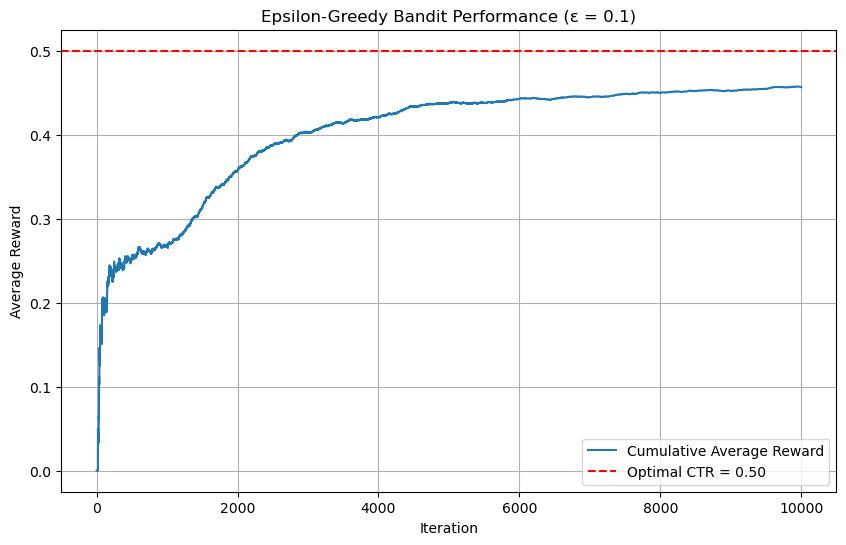

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(avg_reward, label="Cumulative Average Reward")
plt.axhline(y=0.5, color='red', linestyle='--', label="Optimal CTR = 0.50")
plt.xlabel("Iteration")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy Bandit Performance (ε = 0.1)")
plt.legend()
plt.grid(True)
plt.show()


🔹 Part B: Explore–Exploit Tradeoff
We study how changing ε affects learning behavior.

Run experiments

In [8]:
N = 10000
epsilons = [0.01, 0.1, 0.5]

results = {}

for eps in epsilons:
    results[eps] = run_bandit(eps, N)


Combined plot

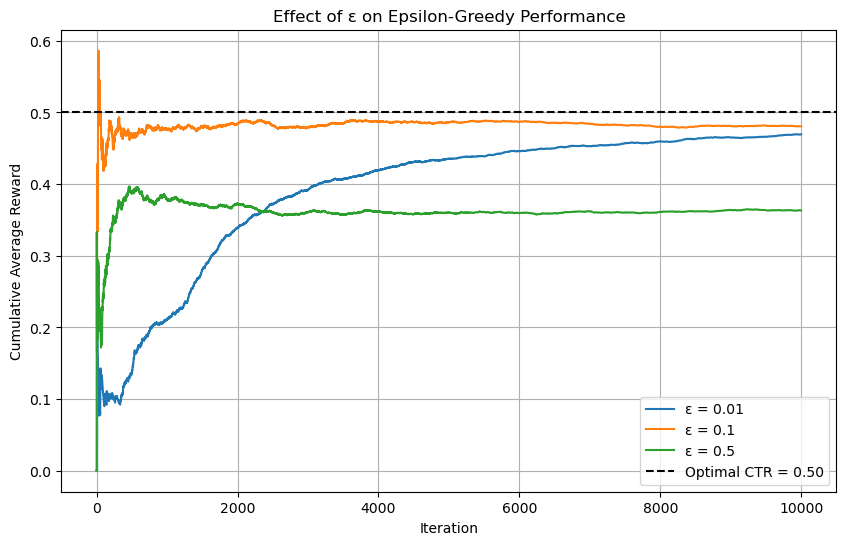

In [10]:
plt.figure(figsize=(10, 6))

for eps, avg_reward in results.items():
    plt.plot(avg_reward, label=f"ε = {eps}")

plt.axhline(y=0.5, color='black', linestyle='--', label="Optimal CTR = 0.50")

plt.xlabel("Iteration")
plt.ylabel("Cumulative Average Reward")
plt.title("Effect of ε on Epsilon-Greedy Performance")
plt.legend()
plt.grid(True)
plt.show()
